<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
    Temas Selectos: Python para Ciencias de la Tierra
  </span>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 4: Análisis espectral y series de tiempo </span><br/>
  <span style="color:DodgerBlue; font-size:140%;">Notebook: La Transformada de Fourier — fundamentos e interpretación </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2026-II</span>
</p>

---

# <font color="darkblue"> Introducción </font>

Muchas de las señales que estudiamos en ciencias de la Tierra —sismos, mareas, variaciones de temperatura, registros de presión atmosférica— parecen caóticas a primera vista. Sin embargo, la mayor parte de ellas esconden una **estructura periódica**: oscilaciones que se repiten a distintas frecuencias y que, una vez identificadas, nos dicen algo físicamente significativo sobre el sistema que las produce.

La **Transformada de Fourier** es la herramienta matemática que nos permite pasar del dominio del tiempo (¿cómo varía la señal segundo a segundo?) al **dominio de la frecuencia** (¿qué tan fuerte oscila la señal a cada frecuencia?). Esta "traducción" es posible gracias a una idea elegante: **cualquier señal periódica puede descomponerse como una suma de senos y cosenos**, cada uno con su propia frecuencia, amplitud y fase.

En este notebook construiremos esa intuición de forma progresiva. Primero recordaremos qué son los senos y cosenos y cómo se combinan para formar señales más complejas. Luego formalizaremos la idea con la **Serie de Fourier** y finalmente llegaremos a la **Transformada Discreta de Fourier (DFT)**, que es lo que usamos en la práctica con datos reales.

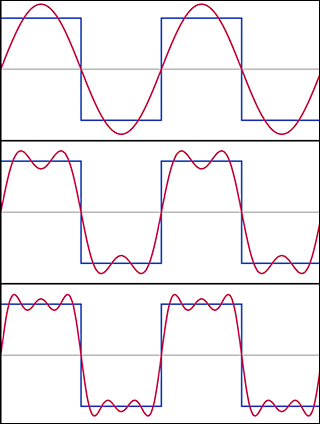

---

# <font color="darkblue"> 1. El lenguaje de las oscilaciones: senos y cosenos </font>

Antes de entrar a Fourier, vale la pena recordar por qué los senos y cosenos son los "bloques de construcción" naturales para describir oscilaciones.

Una onda sinusoidal queda completamente caracterizada por tres parámetros:

$$x(t) = A \cos(2\pi f t + \phi)$$

| Parámetro | Símbolo | Significado físico |
|-----------|---------|--------------------|
| **Amplitud** | $A$ | Qué tan intensa es la oscilación |
| **Frecuencia** | $f$ | Cuántos ciclos ocurren por unidad de tiempo (Hz) |
| **Fase** | $\phi$ | En qué punto del ciclo empieza la onda |

El **período** $T = 1/f$ es el tiempo que tarda en completarse un ciclo.

### ¿Por qué senos *y* cosenos?

El coseno y el seno son la misma función desplazada $90°$ ($\pi/2$ radianes). Incluir ambos nos da la libertad de representar cualquier fase posible. De hecho, siempre podemos reescribir:

$$A \cos(2\pi f t + \phi) = A\cos(\phi)\underbrace{\cos(2\pi f t)}_{\text{parte par}} - A\sin(\phi)\underbrace{\sin(2\pi f t)}_{\text{parte impar}}$$

Es decir, **la amplitud y la fase de una oscilación quedan codificadas en los coeficientes que acompañan al coseno y al seno** de esa misma frecuencia. Fourier aprovecha exactamente esto.

### La idea central de Fourier

> **Cualquier señal periódica** $x(t)$ con período $T$ puede escribirse como una suma (posiblemente infinita) de senos y cosenos cuyas frecuencias son múltiplos enteros de la frecuencia fundamental $f_0 = 1/T$:
>
> $$x(t) = \frac{a_0}{2} + \sum_{n=1}^{\infty} \Big[ a_n \cos(2\pi n f_0 t) + b_n \sin(2\pi n f_0 t) \Big]$$
>
> Los coeficientes $a_n$ y $b_n$ nos dicen **cuánto contribuye cada frecuencia** a la señal total.

Estos múltiplos de $f_0$ se llaman **armónicos**. El primero ($n=1$) es la frecuencia fundamental; el segundo ($n=2$) es el primer armónico, y así sucesivamente. Cada armónico aporta un "sabor" diferente a la forma de la onda.

En los siguientes apartados veremos esto en acción: construiremos señales complejas sumando senos y cosenos, y luego aprenderemos a hacer el proceso inverso —descomponer una señal en sus componentes frecuenciales— con la Transformada de Fourier.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## <font color="RoyalBlue"> 1a. Efecto de la amplitud $A$ </font>

La amplitud escala la onda verticalmente. No cambia la forma ni la frecuencia — solo "estira" o "achica" la oscilación.

In [4]:
x = np.linspace(0, 4*np.pi, 500)
k = 1.0                        # número de onda fijo
amplitudes = [0.5, 1.0, 2.0]

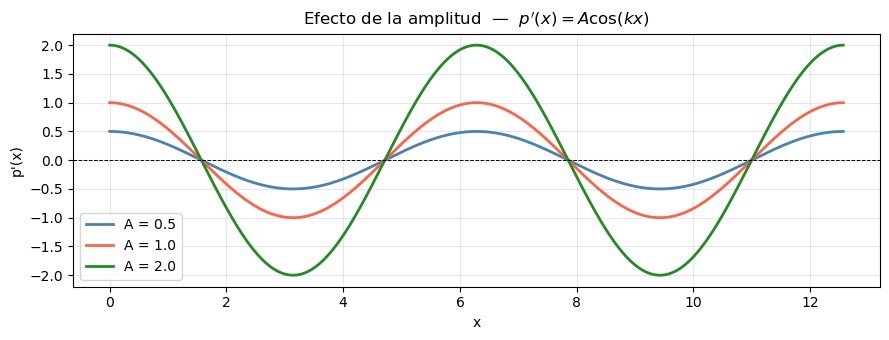

In [5]:
colores    = ['steelblue', 'tomato', 'forestgreen']

fig, ax = plt.subplots(figsize=(9, 3.5))

for A, color in zip(amplitudes, colores):
    ax.plot(x, A * np.cos(k * x), color=color, linewidth=2, label=f'A = {A}')

ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel("p'(x)")
ax.set_title('Efecto de la amplitud  —  $p\'(x) = A\\cos(kx)$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## <font color="RoyalBlue"> 1b. Efecto del número de onda $k$ </font>

El número de onda $k = 2\pi / \lambda$ controla la **longitud de onda** $\lambda$: cuánto espacio ocupa un ciclo completo. Un $k$ más grande significa ciclos más cortos (más apretados).

In [17]:
numeros_de_onda = [1.0, 2.0, 3.0]

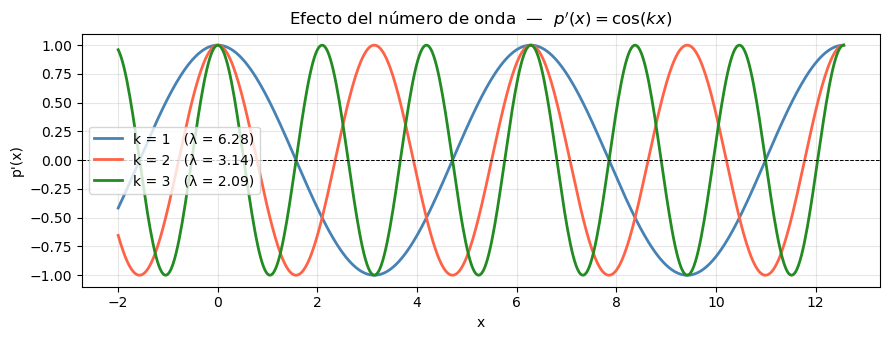

In [18]:
colores         = ['steelblue', 'tomato', 'forestgreen']

fig, ax = plt.subplots(figsize=(9, 3.5))

for k, color in zip(numeros_de_onda, colores):
    lam = 2 * np.pi / k
    ax.plot(x, np.cos(k * x), color=color, linewidth=2,
            label=f'k = {k:.0f}   (λ = {lam:.2f})')

ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel("p'(x)")
ax.set_title('Efecto del número de onda  —  $p\'(x) = \\cos(kx)$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## <font color="RoyalBlue"> 1c. Efecto de la fase $\phi$ </font>

La fase **desplaza horizontalmente** la onda sin cambiar su forma ni su amplitud. Una fase de $\pi/2$ convierte un coseno en un seno: $\cos(kx + \pi/2) = -\sin(kx)$.

> **Nota:** En Fourier, la fase es importante porque determina cómo se combinan las diferentes componentes al reconstruir la señal original.

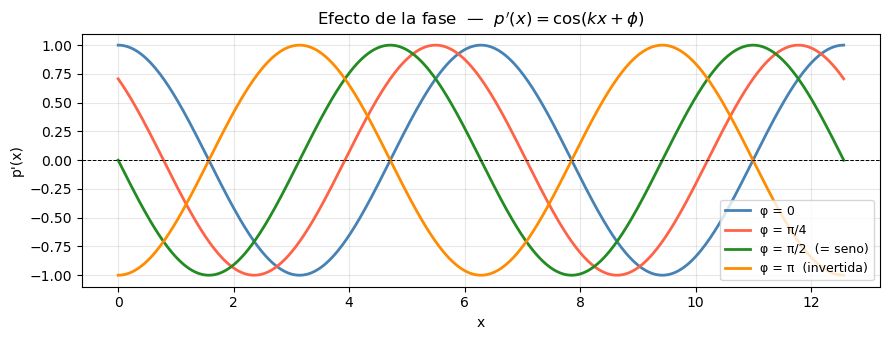

In [7]:
fases   = [0, np.pi/4, np.pi/2, np.pi]
etiquetas = ['φ = 0', 'φ = π/4', 'φ = π/2  (= seno)', 'φ = π  (invertida)']
colores = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 3.5))

for phi, etiqueta, color in zip(fases, etiquetas, colores):
    ax.plot(x, np.cos(x + phi), color=color, linewidth=2, label=etiqueta)

ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel("p'(x)")
ax.set_title('Efecto de la fase  —  $p\'(x) = \\cos(kx + \\phi)$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

---

# <font color="darkblue"> 2. Introduciendo el tiempo: onda viajera </font>

La expresión anterior solo depende de $x$, así que describe una estructura espacial **fija**. Si queremos que la onda evolucione en el tiempo, introducimos una fase dependiente de $t$:

$$p'(x,t) = A\cos(kx - \omega t)$$

donde $\omega$ es la **frecuencia angular** (radianes por unidad de tiempo). El signo negativo hace que el patrón se desplace hacia la derecha. La **velocidad de fase** es:

$$c = \frac{\omega}{k}$$

Una forma útil de pensarlo: el patrón no desaparece, simplemente se mueve.

In [22]:
x = np.linspace(-2,3*np.pi, 500)
k     = 1.0
omega = 1.5
tiempos = [0, 0.8, 1.6, 2.4]

Velocidad de fase:  c = ω/k = 1.500


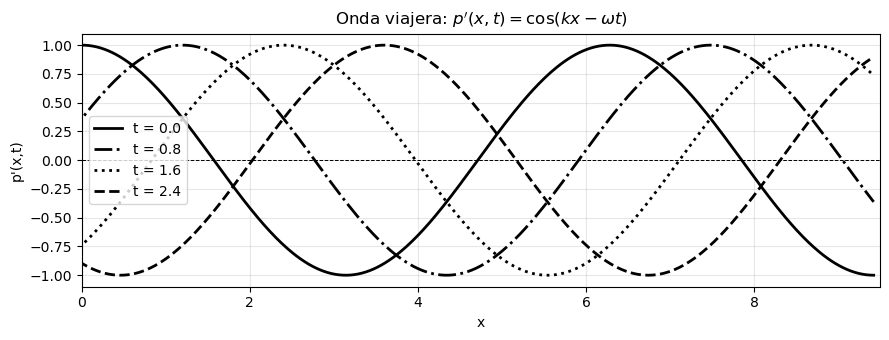

In [24]:
ls  = ['-','-.',':','--']

fig, ax = plt.subplots(figsize=(9, 3.5))

for t, linestyle in zip(tiempos, ls):
    ax.plot(x, np.cos(k*x - omega*t), color='k', linewidth=2, linestyle=linestyle, label=f't = {t:.1f}')

ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlim([0, 9.5])
ax.set_xlabel('x')
ax.set_ylabel("p'(x,t)")
ax.set_title("Onda viajera: $p'(x,t) = \\cos(kx - \\omega t)$")
ax.legend()
ax.grid(True, alpha=0.3)

print(f'Velocidad de fase:  c = ω/k = {omega/k:.3f}')
plt.tight_layout()

---

<a name='ej-fourier-1'></a>
### **<font color="DodgerBlue">Ejercicio 1 - Superposición de ondas viajeras </font>**

<font color="DarkBlue"> En este ejercicio construirá y visualizará ondas viajeras de la forma $p'(x,t) = A\cos(kx - \omega t)$, combinando distintos valores de número de onda $k$ y frecuencia angular $\omega$.

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Defina una grilla espacial $x \in [0, 4\pi]$ y un instante de tiempo fijo $t = 0$. Elija dos pares de parámetros $(k_1, \omega_1)$ y $(k_2, \omega_2)$ con valores distintos, de manera que las dos ondas tengan **longitudes de onda y velocidades de fase diferentes**. Grafique las dos ondas individuales y su suma en una figura con tres paneles apilados. Etiquete cada panel indicando los valores de $k$, $\omega$ y la velocidad de fase $c = \omega/k$ correspondiente.

<font color="DarkBlue"> 2. Repita la visualización anterior, pero ahora para **tres instantes de tiempo distintos** ($t = 0$, $t = 1$, $t = 2$), mostrando solo la onda resultante (la suma). Grafique los tres instantes en la misma figura usando colores distintos. ¿Se propaga la señal compuesta a una velocidad bien definida? ¿Qué observa?

<font color="DarkBlue"> 3. Calcule e imprima las siguientes cantidades para cada onda individual: longitud de onda $\lambda = 2\pi/k$, período temporal $T = 2\pi/\omega$ y velocidad de fase $c = \omega/k$. ¿Qué combinación de parámetros produce la onda que se propaga más rápido? ¿Cuál tiene los ciclos más cortos en el espacio?

<font color="DarkBlue"> 4. En un párrafo breve (en una celda markdown), interprete los resultados. ¿Qué diferencia se observa entre la suma de dos ondas con velocidades de fase similares frente a velocidades muy distintas? ¿En qué tipo de fenómenos geofísicos esperaría encontrar la superposición de ondas con estas características?

---

---

# <font color="darkblue"> 3. Superposición </font>

Muchas señales reales no son una sola onda pura. Con frecuencia pueden verse como la **suma de varias ondas**:

$$p'(t) = A_1\cos(\omega_1 t) + A_2\cos(\omega_2 t) + \cdots$$

Esta idea de **superposición** es central en física y en análisis de datos. La pregunta natural es:

> Si me das una señal complicada, ¿cómo recupero las frecuencias que la forman?

Aquí entra Fourier.

In [25]:
t = np.linspace(0, 10, 1000)

# Componentes individuales
A1, f1 = 1.0, 1.0     # amplitud y frecuencia de la componente 1
A2, f2 = 0.5, 3.0     # amplitud y frecuencia de la componente 2

onda1 = A1 * np.cos(2*np.pi * f1 * t)
onda2 = A2 * np.cos(2*np.pi * f2 * t)
suma  = onda1 + onda2

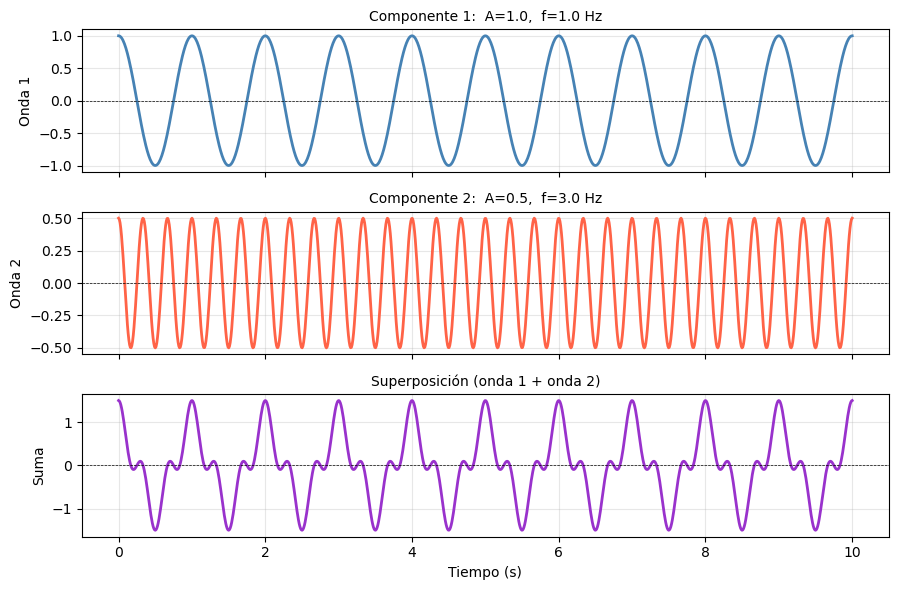

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t, onda1, color='steelblue', linewidth=2)
axes[0].set_ylabel('Onda 1')
axes[0].set_title(f'Componente 1:  A={A1},  f={f1} Hz', fontsize=10)

axes[1].plot(t, onda2, color='tomato', linewidth=2)
axes[1].set_ylabel('Onda 2')
axes[1].set_title(f'Componente 2:  A={A2},  f={f2} Hz', fontsize=10)

axes[2].plot(t, suma, color='darkorchid', linewidth=2)
axes[2].set_ylabel('Suma')
axes[2].set_title('Superposición (onda 1 + onda 2)', fontsize=10)
axes[2].set_xlabel('Tiempo (s)')

for ax in axes:
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

plt.tight_layout()

---

# <font color="darkblue"> 4. Serie de Fourier: idea básica </font>

La serie de Fourier dice que, bajo condiciones bastante generales, una función periódica puede escribirse como suma de senos y cosenos:

$$f(t) = \frac{a_0}{2} + \sum_{n=1}^{\infty} \left[ a_n \cos(n\omega_0 t) + b_n \sin(n\omega_0 t) \right]$$

donde:

- $\omega_0 = 2\pi/T$ es la **frecuencia angular fundamental**,
- $a_n$ y $b_n$ son **coeficientes** que indican cuánto contribuye cada armónico.

La interpretación es directa:
- **dominio del tiempo**: vemos cómo cambia la señal;
- **dominio de la frecuencia**: vemos qué frecuencias contiene.

El ejemplo clásico es la **onda cuadrada**: una señal que alterna entre $+1$ y $-1$. Su serie de Fourier es una suma infinita de armónicos impares:

$$f(t) = \frac{4}{\pi} \sum_{n=1,3,5,\ldots} \frac{1}{n} \sin(n\omega_0 t)$$

La siguiente celda muestra cómo agregar más armónicos mejora la aproximación.

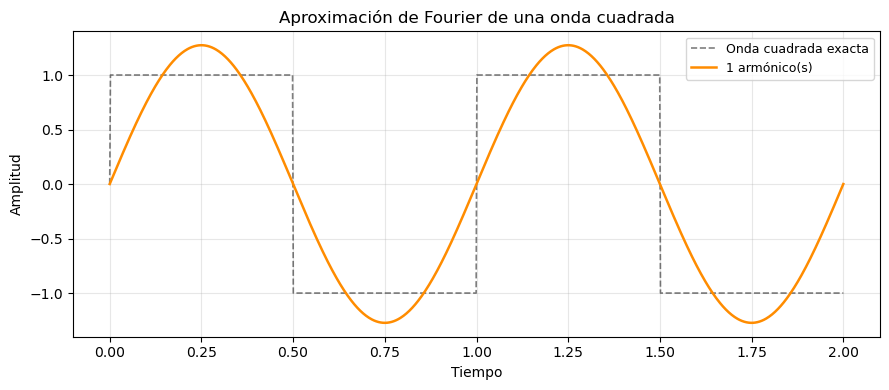

In [10]:
t = np.linspace(0, 2, 1000)
omega0 = 2 * np.pi        # período = 1

# Onda cuadrada real (referencia)
cuadrada = np.sign(np.sin(omega0 * t))

# Aproximaciones con distinto número de armónicos
harmonicos = [1, 3, 7, 19]
colores     = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(t, cuadrada, 'k--', linewidth=1.2, alpha=0.5, label='Onda cuadrada exacta')
aprox = np.zeros_like(t)
n=1
    # solo armónicos impares
aprox += (4 / (np.pi * n)) * np.sin(n * omega0 * t)
ax.plot(t, aprox, color=color, linewidth=1.8, label=f'{1} armónico(s)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Amplitud')
ax.set_title('Aproximación de Fourier de una onda cuadrada')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [27]:
t = np.linspace(0, 2, 1000)
omega0 = 2 * np.pi        # período = 1

# Onda cuadrada real (referencia)
cuadrada = np.sign(np.sin(omega0 * t))

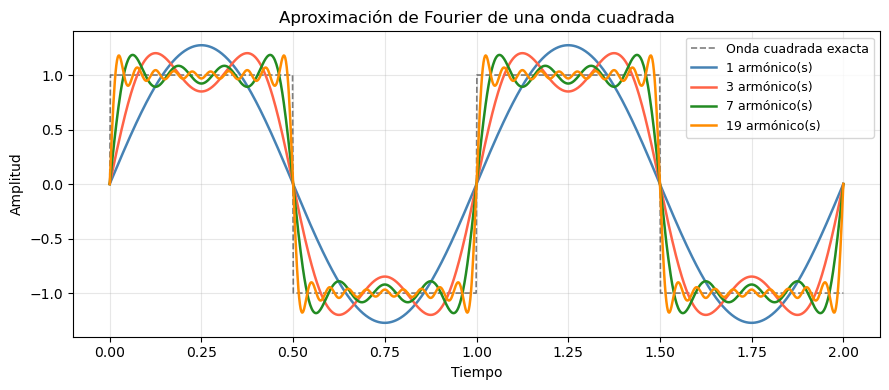

In [28]:
# Aproximaciones con distinto número de armónicos
harmonicos = [1, 3, 7, 19]
colores     = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(t, cuadrada, 'k--', linewidth=1.2, alpha=0.5, label='Onda cuadrada exacta')

for N, color in zip(harmonicos, colores):
    aprox = np.zeros_like(t)
    for n in range(1, N + 1, 2):              # solo armónicos impares
        aprox += (4 / (np.pi * n)) * np.sin(n * omega0 * t)
    ax.plot(t, aprox, color=color, linewidth=1.8, label=f'{N} armónico(s)')

ax.set_xlabel('Tiempo')
ax.set_ylabel('Amplitud')
ax.set_title('Aproximación de Fourier de una onda cuadrada')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

---

<a name='ej-fourier-2'></a>
### **<font color="DodgerBlue">Ejercicio 2 - Armónicos y construcción de señales </font>**

<font color="DarkBlue"> Dada una señal periódica con frecuencia fundamental $f_0$, sus **armónicos** son sinusoides cuya frecuencia es un múltiplo entero de $f_0$:

$$h_n(t) = A_n \cos(2\pi \cdot n f_0 \cdot t), \quad n = 1, 2, 3, \ldots$$

<font color="DarkBlue"> El caso $n=1$ es la propia fundamental; $n=2$ oscila el doble de rápido, $n=3$ el triple, y así sucesivamente. La amplitud $A_n$ de cada armónico determina cuánto contribuye a la forma final de la señal.

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Defina una frecuencia fundamental $f_0$ y grafique sus primeros cuatro armónicos en paneles apilados. Etiquete cada panel con $n$ y la frecuencia correspondiente.

<font color="DarkBlue"> 2. Sume los cuatro armónicos usando amplitudes $A_n = 1/n$ y grafique la señal resultante junto a sus componentes en una sola figura.

<font color="DarkBlue"> 3. En una celda markdown, responda: ¿qué le ocurre a la señal compuesta si elimina el primer armónico ($n=1$)? ¿Y si solo conserva los armónicos impares ($n=1,3$)?

---

---

# <font color="darkblue"> 5. Aplicación: serie de tiempo sintética </font>

Ahora generaremos una señal artificial que combina dos ondas con ruido:

$$s(t) = A_1 \cos(2\pi f_1 t) + A_2 \cos(2\pi f_2 t) + \text{ruido}$$

Después usaremos la **FFT** (*Fast Fourier Transform*) para recuperar las frecuencias originales a partir de la señal ruidosa. Este es exactamente el problema que enfrentamos al analizar datos reales.

In [12]:
np.random.seed(42)

dt = 0.1                     # intervalo de muestreo (s)
t  = np.arange(0, 100, dt)

f1, A1 = 0.05, 1.2           # frecuencia 1 (Hz) y amplitud
f2, A2 = 0.15, 0.7           # frecuencia 2 (Hz) y amplitud

signal_clean = A1*np.cos(2*np.pi*f1*t) + A2*np.cos(2*np.pi*f2*t)
ruido        = 0.45 * np.random.randn(len(t))
signal       = signal_clean + ruido

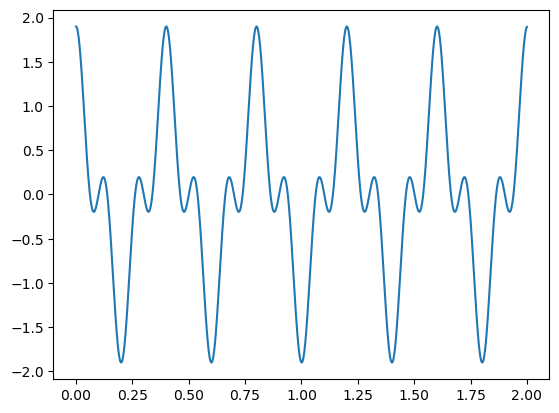

In [29]:
plt.plot(t,signal_clean)

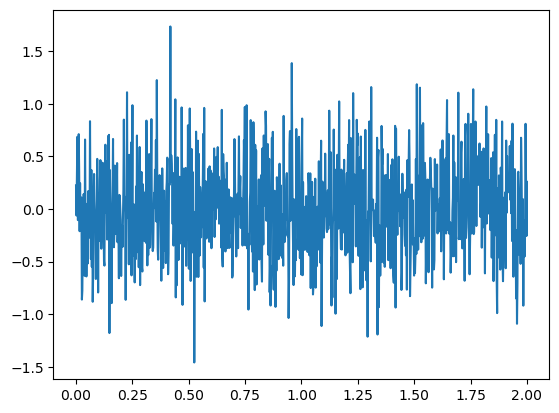

In [30]:
plt.plot(t,ruido)

In [13]:
print(np.mean(signal),np.mean(signal_clean))

0.008699425120046513 2.842170943040401e-17


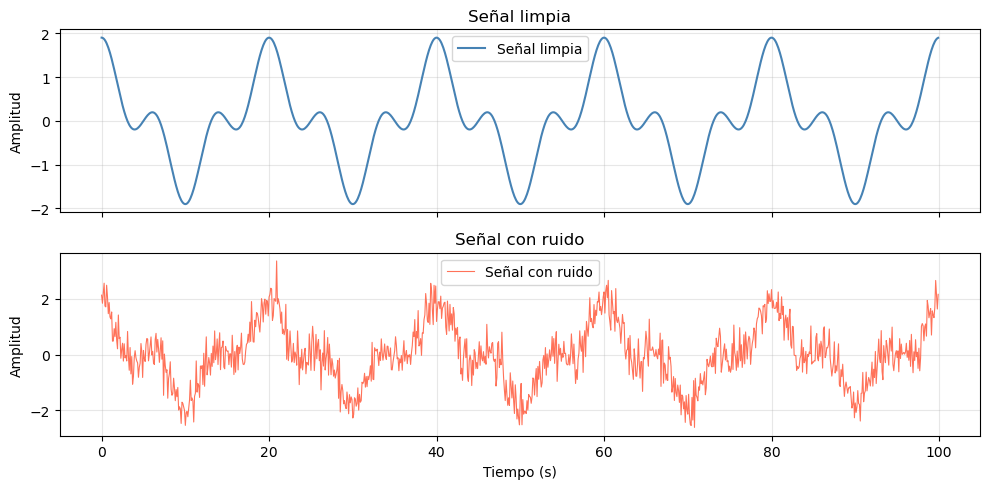

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t, signal_clean, color='steelblue', linewidth=1.5, label='Señal limpia')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Señal limpia')
axes[0].legend()

axes[1].plot(t, signal, color='tomato', linewidth=0.8, alpha=0.9, label='Señal con ruido')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('Señal con ruido')
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()

---

# <font color="darkblue"> 5.5. ¿Qué tan parecida es la señal a un armónico? </font>

Antes de aplicar la FFT necesitamos entender qué es lo que calcula. La pregunta central es:

> Dada una señal $s(t)$, ¿cuánto se parece a un coseno de frecuencia $f$?

La respuesta es sorprendentemente directa: **multiplicamos la señal por ese coseno y sumamos**. 
A esa operación se le llama **producto interno** entre la señal y el armónico:

$$C(f) = \sum_{n} s(t_n)\, \cos(2\pi f\, t_n)$$

La intuición es geométrica:
- Si $s(t)$ oscila **en fase** con $\cos(2\pi f t)$, los productos $s(t_n)\cdot\cos(2\pi f t_n)$ son mayoritariamente **positivos** → la suma es **grande**.
- Si $s(t)$ no tiene nada que ver con esa frecuencia, los productos positivos y negativos se **cancelan** → la suma es **cercana a cero**.

La Transformada de Fourier no es más que calcular ese escalar $C(f)$ para **todas las frecuencias posibles** de forma simultánea y eficiente.

In [31]:
# Señal sintética con una sola frecuencia conocida
t = np.linspace(0, 10, 1000)
f_señal = 2.0
# aqui se define la señal como un coseno
s = np.cos(2 * np.pi * f_señal * t)

# Calculamos el producto interno contra distintas frecuencias de prueba
frecuencias_prueba = np.linspace(0.5, 5.0, 500)
productos_internos = [np.sum(s * np.cos(2 * np.pi * f * t)) for f in frecuencias_prueba]

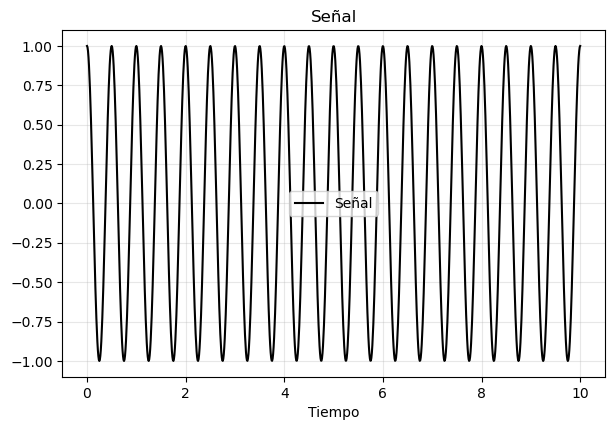

In [37]:
fig, axes = plt.subplots(1,1, figsize=(7, 4.5))
plt.plot(t,s,c='k',label='Señal')
plt.legend()
plt.title('Señal')
plt.xlabel('Tiempo')
plt.grid(True, alpha=0.3)

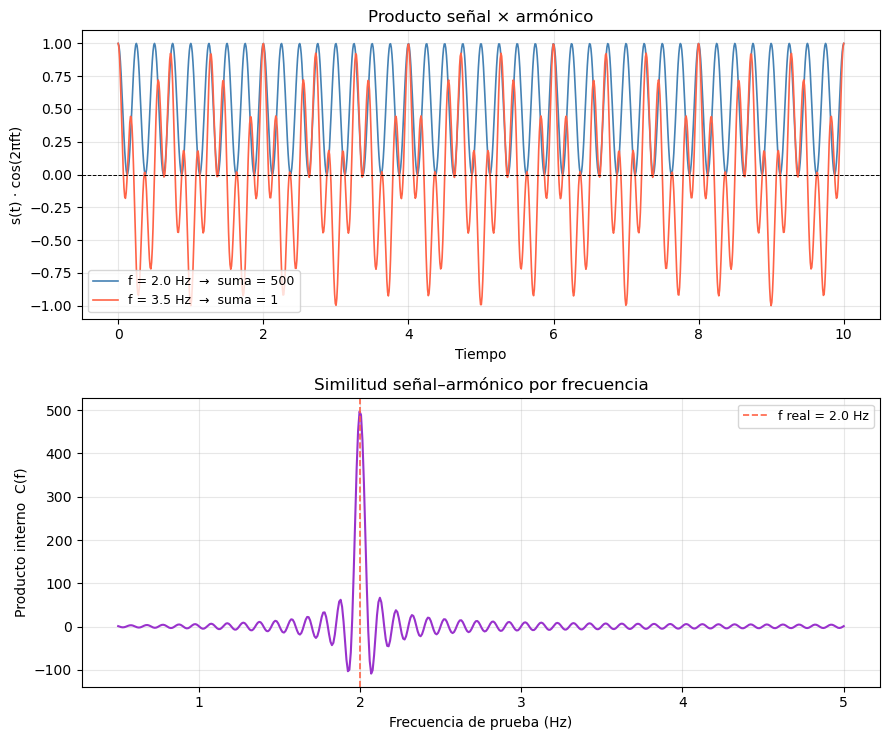

In [34]:
fig, axes = plt.subplots(2,1, figsize=(9, 7.5))

# Panel izquierdo: ejemplo visual de un "buen match" y un "mal match"
f_buena = 2.0
f_mala  = 3.5
producto_bueno = s * np.cos(2 * np.pi * f_buena * t)
producto_malo  = s * np.cos(2 * np.pi * f_mala  * t)

axes[0].plot(t, producto_bueno, color='steelblue', linewidth=1.2,
             label=f'f = {f_buena} Hz  →  suma = {np.sum(producto_bueno):.0f}')
axes[0].plot(t, producto_malo,  color='tomato',    linewidth=1.2,
             label=f'f = {f_mala} Hz  →  suma = {np.sum(producto_malo):.0f}')
axes[0].axhline(0, color='k', linewidth=0.7, linestyle='--')
axes[0].set_xlabel('Tiempo')
axes[0].set_ylabel('s(t) · cos(2πft)')
axes[0].set_title('Producto señal × armónico')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel derecho: el producto interno como función de la frecuencia de prueba
axes[1].plot(frecuencias_prueba, productos_internos, color='darkorchid', linewidth=1.5)
axes[1].axvline(f_señal, color='tomato', linestyle='--', linewidth=1.2, label=f'f real = {f_señal} Hz')
axes[1].set_xlabel('Frecuencia de prueba (Hz)')
axes[1].set_ylabel('Producto interno  C(f)')
axes[1].set_title('Similitud señal–armónico por frecuencia')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

---

# <font color="darkblue"> 6. Transformada de Fourier de la señal </font>

La **Transformada Discreta de Fourier** (implementada en Python como `np.fft.fft`) descompone una señal en sus componentes frecuenciales. Dada una serie de tiempo $s(t)$, el resultado es un espectro de amplitudes que revela qué frecuencias están presentes y con qué intensidad.

Aplicaremos la FFT para pasar de la serie de tiempo al **espectro de frecuencias**. Los pasos son:

1. Calcular la FFT con `np.fft.fft`.
2. Obtener las frecuencias correspondientes con `np.fft.fftfreq`.
3. Convertir el resultado complejo a amplitud ($|X(f)|$).
4. Quedarnos solo con las frecuencias positivas.

Si todo sale bien, deberían aparecer picos cerca de $f_1$ y $f_2$.

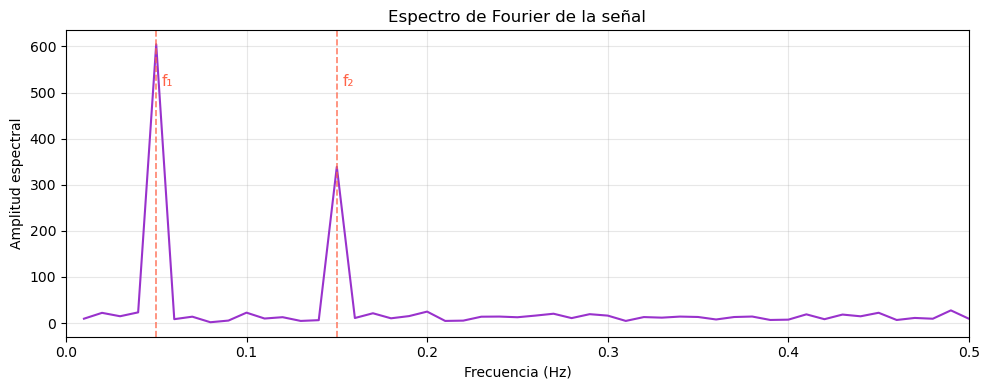

In [15]:
# Calculamos la FFT
fft_vals = np.fft.fft(signal)
freqs    = np.fft.fftfreq(len(t), d=dt)

# Nos quedamos con frecuencias positivas
positivo   = freqs > 0
freqs_pos  = freqs[positivo]
amp_pos    = np.abs(fft_vals[positivo])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs_pos, amp_pos, color='darkorchid', linewidth=1.5)

# Marcamos las frecuencias originales como referencia
for f, A, etiqueta in [(f1, A1, 'f₁'), (f2, A2, 'f₂')]:
    ax.axvline(f, color='tomato', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(f + 0.003, amp_pos.max()*0.85, etiqueta, color='tomato', fontsize=11)

ax.set_xlim(0, 0.5)
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Amplitud espectral')
ax.set_title('Espectro de Fourier de la señal')
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [16]:
# Identificamos los picos dominantes
indices_max = np.argsort(amp_pos)[-5:][::-1]

print('Frecuencias dominantes encontradas:')
print(f'  {"Frecuencia":>12}   {"Amplitud espectral":>20}')
print('  ' + '-'*36)
for i in indices_max:
    print(f'  f = {freqs_pos[i]:>8.4f} Hz     {amp_pos[i]:>10.2f}')

print('\nFrecuencias originales:')
print(f'  f1 = {f1}  Hz   (A1 = {A1})')
print(f'  f2 = {f2} Hz   (A2 = {A2})')

Frecuencias dominantes encontradas:
    Frecuencia     Amplitud espectral
  ------------------------------------
  f =   0.0500 Hz         604.72
  f =   0.1500 Hz         338.91
  f =   2.2100 Hz          33.49
  f =   1.8900 Hz          32.75
  f =   4.1900 Hz          31.87

Frecuencias originales:
  f1 = 0.05  Hz   (A1 = 1.2)
  f2 = 0.15 Hz   (A2 = 0.7)


---

<a name='ej-fourier-3'></a>
### **<font color="DodgerBlue">Ejercicio 3 - Transformada de Fourier de una señal sintética </font>**

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Construya una señal sintética sumando **tres cosenos** con frecuencias, amplitudes y fases de su elección, más un término de ruido aleatorio con `np.random.randn`. Decida si agregará mucho o poco ruido a su señal fijándose bien e la constante que multiplica a su número random, es decir el valor c en la siguiente formula `c * np.random.randn()`.  Grafique la señal resultante en el dominio del tiempo.

<font color="DarkBlue"> 2. Aplique `np.fft.fft` a la señal y construya el eje de frecuencias con `np.fft.fftfreq`. Grafique el espectro de amplitudes ($|X(f)|$) para las frecuencias positivas. Verifique que los picos del espectro correspondan a las frecuencias que usted definió.

<font color="DarkBlue"> 3. En una celda markdown, reflexione sobre lo siguiente: ¿qué tan fácil es identificar las frecuencias en el dominio del tiempo mirando la señal directamente? ¿Qué ventaja ofrece el espectro de Fourier para este propósito?

---

---

<a name='ej-fourier-4'></a>
### **<font color="DodgerBlue">Ejercicio 4 - Espectro de Fourier del índice ONI </font>**

<font color="DarkBlue"> En otro universo paralelo, en el curso de Temas Selectos vimos datos en formato .txt e identificamos episodios de El Niño y La Niña en la serie del índice ONI. 
    
Si no lo recuerda, o está aquí por azares del destino, este es el notebook al que nos referimos: 

https://github.com/JLGarciaFranco/TemasSelectos/blob/main/Notebooks/Unidad_II/U2_2_formatos_datos.ipynb

Y los datos de ONI se encuentran aquí: 

https://github.com/JLGarciaFranco/TemasSelectos/blob/main/data/oni.ascii.txt


Ahora aplicaremos la Transformada de Fourier para responder una pregunta más precisa: **¿cada cuánto tiempo ocurre ENSO?**

<font color="DarkBlue"> Para este ejercicio utilizaremos directamente el dataframe `oni` que ya construimos, tomando la columna `ANOM` como nuestra señal. Dado que cada registro corresponde a una temporada mensual, el intervalo de muestreo es $dt = 1/12$ años.

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Extraiga la columna `ANOM` como un arreglo de NumPy, elimine los valores faltantes con `.dropna()` y defina $dt = 1/12$. Grafique la serie completa en el dominio del tiempo. ¿A simple vista puede identificar una periodicidad dominante?

<font color="DarkBlue"> 2. Aplique `np.fft.fft` a la serie y construya el eje de frecuencias con `np.fft.fftfreq`. Grafique el espectro de amplitudes para las frecuencias positivas. Dado que las frecuencias estarán en ciclos por año, convierta el eje horizontal a **años por ciclo** ($1/f$) para facilitar la interpretación física. Limite el eje entre 1 y 15 años.

<font color="DarkBlue"> 3. En una celda markdown, identifique el pico dominante del espectro e indique a cuántos años corresponde. Compare con lo que sabe sobre la periodicidad típica de ENSO (entre 2 y 7 años). ¿Es consistente el resultado?

---